In [20]:
### Steps
# Create 3 folder  traing, testing and validation.
# Training( 2 folder happy and not happy)

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pylab as plt
import tensorflow as tf
import numpy as np
import cv2
import os

In [2]:
img=image.load_img(r'D:\Education\Datascience\PYTHON_BIGINNER\AI\DeepLearning\Tensorflow\Image Classification\Training\Happy\Happy (20).png')

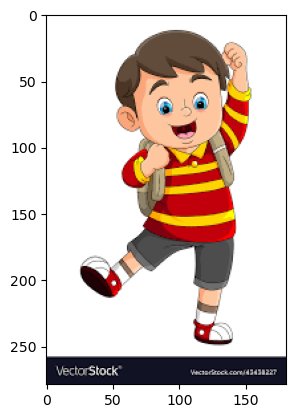

In [3]:
plt.imshow(img)

In [4]:
i1= cv2.imread(r'D:\Education\Datascience\PYTHON_BIGINNER\AI\DeepLearning\Tensorflow\Image Classification\Training\Happy\Happy (20).png')
i1

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 36,  18,  17],
        [ 36,  18,  17],
        [ 36,  18,  17],
        ...,
        [ 36,  18,  17],
        [ 36,  18,  17],
        [ 36,  18,  17]],

       [[ 36,  18,  17],
        [ 36,  18,  17],
        [ 36,  18,  17],
        ...,
        [ 36,  18,  17],
        [ 36,  18,  17],
        [ 36,  18,  17]],

       [[ 36,  18,  17],
        [ 36,  18,  17],
        [ 36,  18,  17],
        ...,
        [ 36,  18,  17],
        [ 36,  18,  17],
        [ 36,  18,  17]]

In [5]:
i1.shape  

(279, 181, 3)

In [6]:
train=ImageDataGenerator(rescale=1/255)
validation=ImageDataGenerator(rescale=1/255)

In [7]:
train_dataset=train.flow_from_directory(r'D:\Education\Datascience\PYTHON_BIGINNER\AI\DeepLearning\Tensorflow\Image Classification\Training',
                                        target_size=(200,200),
                                        batch_size=3,
                                        class_mode='binary')
validation_dataset=validation.flow_from_directory(r'D:\Education\Datascience\PYTHON_BIGINNER\AI\DeepLearning\Tensorflow\Image Classification\validation',
                                                  target_size=(200,200),
                                                  batch_size=3,
                                                  class_mode='binary')

Found 30 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [8]:
train_dataset.class_indices

{'Happy': 0, 'Not Happy': 1}

In [9]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [19]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['acc'])

In [29]:
# # model_fit=model.fit(train_dataset,
# #                    steps_per_epoch=3,
# #                    epochs=10,
# #                    validation_data=validation_dataset) 

# model_fit = model.fit(
#     train_dataset,
#     steps_per_epoch=3,  # Number of batches per epoch
#     epochs=10,          # Number of epochs
#     validation_data=validation_dataset  # Validation dataset
# )

from tensorflow.keras.preprocessing.image import ImageDataGenerator

valid = ImageDataGenerator(rescale=1./255)

validation_dataset = valid.flow_from_directory(
    r'D:\Education\Datascience\PYTHON_BIGINNER\AI\DeepLearning\Tensorflow\Image Classification\Validation',
    target_size=(200, 200),
    batch_size=3,
    class_mode='binary'
)


Found 30 images belonging to 2 classes.


In [33]:
history.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step - acc: 1.0000 - loss: 0.0028 - val_acc: 1.0000 - val_loss: 0.0131
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 484ms/step - acc: 1.0000 - loss: 0.0248 - val_acc: 1.0000 - val_loss: 0.0119
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 430ms/step - acc: 1.0000 - loss: 0.0031 - val_acc: 1.0000 - val_loss: 0.0207
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 383ms/step - acc: 1.0000 - loss: 7.9491e-04 - val_acc: 1.0000 - val_loss: 0.0185
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 438ms/step - acc: 1.0000 - loss: 0.0055 - val_acc: 1.0000 - val_loss: 0.0067
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step - acc: 1.0000 - loss: 0.0286 - val_acc: 0.7000 - val_loss: 1.2542
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 432ms/step - acc: 0.6389 - loss: 1.6568 - val_acc: 1.0000 - val_loss: 0.0326
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - acc: 1.0000 - loss: 0.0125 - val_acc: 1.0000 - val_loss: 0.0256
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 420ms/step - acc: 1.0000 - lo

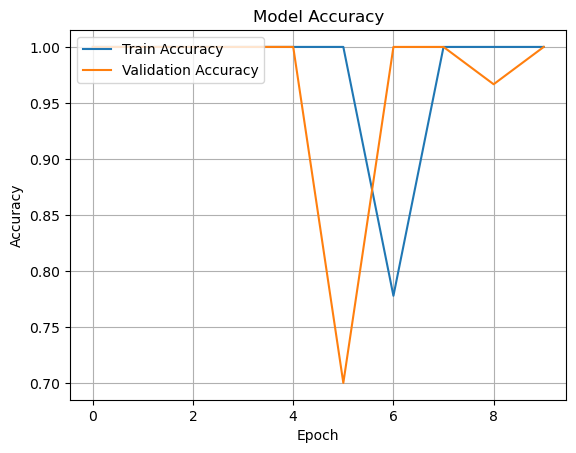

In [34]:
# import keras
# from matplotlib import pyplot as plt
# #history = model1.fit(train_x, train_y,validation_split = 0.1, epochs=50, batch_size=4)
# history=model_fit=model.fit(train_dataset,steps_per_epoch=3,epochs=10,validation_data=validation_dataset) 
# plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
# plt.title('model accuracy')
# plt.ylabel('accuracy')
# plt.xlabel('epoch')
# plt.legend(['train', 'val'], loc='upper left')
# plt.show()

import keras
from matplotlib import pyplot as plt

# Fit the model
history = model.fit(
    train_dataset,
    steps_per_epoch=3,
    epochs=10,
    validation_data=validation_dataset
)

# Plot Accuracy
plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


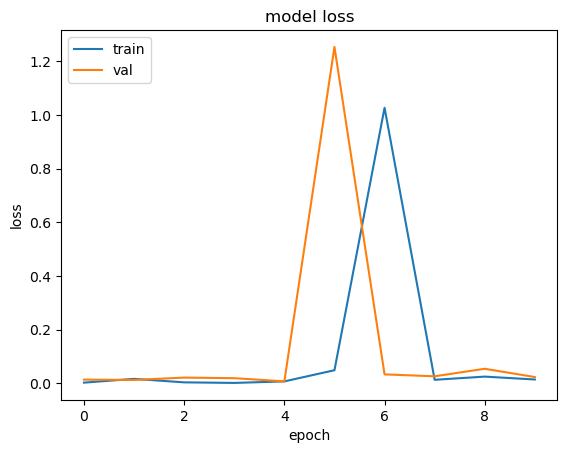

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()